# KHÁM PHÁ VÀ HIỂU SÂU DỮ LIỆU ĐẶT PHÒNG KHÁCH SẠN (HOTEL BOOKING DATA UNDERSTANDING)

Notebook này thực hiện quá trình **Data Understanding & Exploratory Data Analysis (EDA)** toàn diện trên tập dữ liệu `hotel_bookings.csv`.

---

## Mục tiêu phân tích
1. **Hiểu rõ cấu trúc tổng quan**: Kích thước, kiểu dữ liệu, ý nghĩa 32 trường thông tin nghiệp vụ.
2. **Đánh giá sức khỏe dữ liệu (Data Health Check)**: Kiểm tra Missing values, Duplicates, Anomalies (dữ liệu bất thường/vô lý).
3. **Thống kê mô tả (Descriptive Statistics)**: Phân tích phân phối của các biến số và biến định tính.
4. **Khai phá các mô hình nghiệp vụ then chốt (Key Business Insights)**:
- Tỷ lệ hủy phòng (`is_canceled`) giữa Resort Hotel và City Hotel.
- Tính thời vụ & Xu hướng đặt phòng theo các tháng/năm.
- Thời gian đặt trước (`lead_time`) và ảnh hưởng đến việc hủy phòng.
- Giá phòng trung bình ngày (`ADR`) và doanh thu theo loại phòng, loại khách.
- Phân khúc khách hàng (`market_segment`, `customer_type`) & Kênh phân phối (`distribution_channel`).
- Phân bố địa lý khách hàng quốc tế.
5. **Tổng kết các vấn đề phát hiện được** để chuẩn bị cho bước làm sạch trong `cleaning.ipynb`.

## 1. Khởi tạo môi trường & Nạp dữ liệu
Import các thư viện phân tích dữ liệu và trực quan hóa chuyên dụng (`pandas`, `numpy`, `matplotlib`, `seaborn`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_palette('deep')
pd.set_option('display.max_columns', 40)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print("Đã nạp đầy đủ các thư viện cần thiết!")

Đã nạp đầy đủ các thư viện cần thiết!


### Đọc file dữ liệu `Data/hotel_bookings.csv`

In [2]:
df = pd.read_csv('Data/hotel_bookings.csv')

print(f"Kích thước dữ liệu: {df.shape[0]:,} dòng và {df.shape[1]} cột")

📊 Kích thước dữ liệu: 119,390 dòng và 32 cột


## 2. Khám phá tổng quan cấu trúc dữ liệu (Data Overview)

In [3]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.00,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.00,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.00,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.00,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.00,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.00,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.00,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03


In [4]:
df.tail()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
119385,City Hotel,0,23,2017,August,35,30,2,5,2,0.00,0,BB,BEL,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,394.00,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,0.00,0,BB,FRA,Online TA,TA/TO,0,0,0,E,E,0,No Deposit,9.00,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,0.00,0,BB,DEU,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,9.00,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,0.00,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,89.00,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07
119389,City Hotel,0,205,2017,August,35,29,2,7,2,0.00,0,HB,DEU,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,9.00,NaN,0,Transient,151.20,0,2,Check-Out,2017-09-07


### Kiểm tra thông tin các cột, kiểu dữ liệu và giá trị non-null

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

### Bảng phân loại 32 trường dữ liệu theo nghiệp vụ khách sạn

| Nhóm nghiệp vụ | Tên các cột | Ý nghĩa thực tế |
| :--- | :--- | :--- |
| **Thông tin khách sạn** | `hotel` | Loại khách sạn: *City Hotel* (Khách sạn thành phố) hoặc *Resort Hotel* (Khu nghỉ dưỡng). |
| **Trạng thái hủy & đặt** | `is_canceled`, `reservation_status`, `reservation_status_date` | `is_canceled` (1: Đã hủy, 0: Không hủy); Trạng thái cụ thể: *Check-Out, Canceled, No-Show*. |
| **Thời gian lưu trú & Đến** | `lead_time`, `arrival_date_year`, `arrival_date_month`, `arrival_date_week_number`, `arrival_date_day_of_month`, `stays_in_weekend_nights`, `stays_in_week_nights` | Số ngày đặt trước (`lead_time`), ngày tháng năm đến, số đêm ở ngày trong tuần & cuối tuần. |
| **Thông tin khách hàng** | `adults`, `children`, `babies`, `country`, `is_repeated_guest`, `customer_type` | Số người lớn, trẻ em, trẻ sơ sinh; Quốc gia nguồn gốc; Khách quay lại; Phân loại khách (*Transient, Contract, Group...*). |
| **Kênh phân phối & Tiếp thị** | `market_segment`, `distribution_channel`, `agent`, `company` | Phân khúc thị trường (*Online TA, Direct, Corporate...*), Kênh phân phối (*TA/TO, Direct, GDS...*), Mã ID đại lý/công ty. |
| **Phòng & Dịch vụ** | `reserved_room_type`, `assigned_room_type`, `meal`, `booking_changes`, `days_in_waiting_list`, `required_car_parking_spaces`, `total_of_special_requests` | Loại phòng đặt vs nhận; Gói ăn (*BB, HB, FB, SC*); Số lần đổi thông tin; Số ngày chờ; Yêu cầu đỗ xe & yêu cầu đặc biệt. |
| **Tài chính & Thanh toán** | `adr`, `deposit_type`, `previous_cancellations`, `previous_bookings_not_canceled` | `adr` (Average Daily Rate - Giá phòng trung bình/ngày); Loại tiền cọc (*No Deposit, Non Refund, Refundable*); Lịch sử hủy/không hủy. |

## 3. Thống kê mô tả (Descriptive Statistics)

### 3.1 Thống kê các biến định lượng (Numerical Features)

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.00,0.37,0.48,0.00,0.00,0.00,1.00,1.00
lead_time,119390.00,104.01,106.86,0.00,18.00,69.00,160.00,737.00
arrival_date_year,119390.00,2016.16,0.71,2015.00,2016.00,2016.00,2017.00,2017.00
arrival_date_week_number,119390.00,27.17,13.61,1.00,16.00,28.00,38.00,53.00
arrival_date_day_of_month,119390.00,15.80,8.78,1.00,8.00,16.00,23.00,31.00
stays_in_weekend_nights,119390.00,0.93,1.00,0.00,0.00,1.00,2.00,19.00
stays_in_week_nights,119390.00,2.50,1.91,0.00,1.00,2.00,3.00,50.00
adults,119390.00,1.86,0.58,0.00,2.00,2.00,2.00,55.00
children,119386.00,0.10,0.40,0.00,0.00,0.00,0.00,10.00
babies,119390.00,0.01,0.10,0.00,0.00,0.00,0.00,10.00


**Nhận xét nhanh từ thống kê mô tả:**
1. `lead_time`: Trung bình khoảng 104 ngày, có trường hợp đặt trước tới 737 ngày (~2 năm).
2. `adr` (Giá phòng trung bình/ngày): Giá trị trung bình ~101.8, nhưng có giá trị âm (`-6.38`) và giá trị cực lớn (`5400.00`) -> Dấu hiệu của **Outliers / dữ liệu lỗi**.
3. `adults`, `children`, `babies`: Min đều bằng 0, cần kiểm tra xem có dòng nào cả 3 chỉ số này đều bằng 0 hay không (đặt phòng ma/không có người).
4. `is_canceled`: Tỷ lệ hủy phòng trung bình ~37% trên toàn bộ tập dữ liệu.

### 3.2 Thống kê các biến định tính / phân loại (Categorical Features)

In [7]:
df.describe(include='object').T

,count,unique,top,freq
hotel,119390,2,City Hotel,79330
arrival_date_month,119390,12,August,13877
meal,119390,5,BB,92310
country,118902,177,PRT,48590
market_segment,119390,8,Online TA,56477
distribution_channel,119390,5,TA/TO,97870
reserved_room_type,119390,10,A,85994
assigned_room_type,119390,12,A,74053
deposit_type,119390,3,No Deposit,104641
customer_type,119390,4,Transient,89613


## 4. Kiểm tra sức khỏe dữ liệu (Data Health Check)

### 4.1 Kiểm tra giá trị khuyết thiếu (Missing Values)

In [8]:
missing_count = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
'Missing Values': missing_count,
'Percentage (%)': missing_pct
})

missing_df = missing_df[missing_df['Missing Values'] > 0].sort_values(by='Missing Values', ascending=False)
missing_df

,Missing Values,Percentage (%)
company,112593,94.31
agent,16340,13.69
country,488,0.41
children,4,0.00


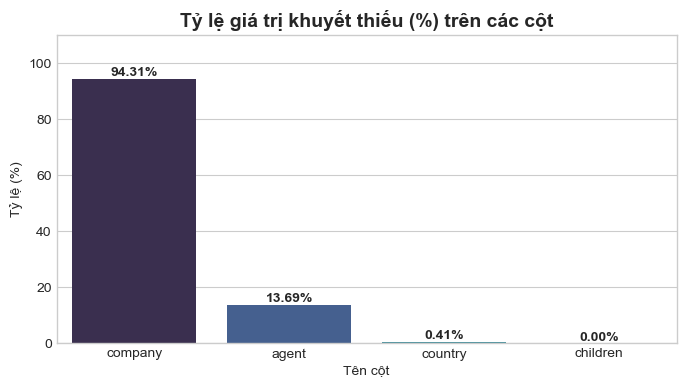

In [9]:
plt.figure(figsize=(8, 4))
sns.barplot(x=missing_df.index, y=missing_df['Percentage (%)'], palette='mako')
plt.title('Tỷ lệ giá trị khuyết thiếu (%) trên các cột', fontsize=14, fontweight='bold')
plt.ylabel('Tỷ lệ (%)')
plt.xlabel('Tên cột')
for i, v in enumerate(missing_df['Percentage (%)']):
    plt.text(i, v + 1, f"{v:.2f}%", ha='center', fontweight='bold')
plt.ylim(0, 110)
plt.show()

**Đánh giá về Missing Values:**
- `company`: Thiếu tới **94.31%** (112,593 dòng). Điều này hợp lý trong thực tế vì đa phần khách cá nhân đặt phòng không thông qua công ty.
- `agent`: Thiếu **13.69%** (16,340 dòng) -> Đại diện cho các khách đặt trực tiếp hoặc không qua đại lý du lịch (OTA).
- `country`: Thiếu **0.41%** (488 dòng) -> Có thể xử lý bằng cách gán giá trị Mode hoặc `'Unknown'`.
- `children`: Chỉ thiếu **4 dòng** -> Có thể điền 0.

### 4.2 Kiểm tra dữ liệu trùng lặp (Duplicate Rows)

In [10]:
duplicate_count = df.duplicated().sum()
duplicate_pct = (duplicate_count / len(df)) * 100

print(f"Tổng số dòng trùng lặp: {duplicate_count:,} dòng ({duplicate_pct:.2f}%)")

Tổng số dòng trùng lặp: 31,994 dòng (26.80%)


### 4.3 Kiểm tra các giá trị bất thường (Anomalies & Inconsistencies)

In [11]:
zero_guests = df[(df['adults'] == 0) & (df['children'] == 0) & (df['babies'] == 0)]
print(f"Số lượng đơn đặt phòng có 0 khách: {len(zero_guests)} dòng")

invalid_adr = df[(df['adr'] <= 0) | (df['adr'] > 5000)]
print(f"Số lượng đơn đặt phòng có ADR <= 0 hoặc > 5000: {len(invalid_adr)} dòng")
print("Chi tiết giá trị cực trị ADR min và max:")
print(f"- Min ADR: {df['adr'].min()}")
print(f"- Max ADR: {df['adr'].max()}")

print("\nSố lượng giá trị 'Undefined':")
print(f"- Cột 'meal': {(df['meal'] == 'Undefined').sum()} dòng")
print(f"- Cột 'market_segment': {(df['market_segment'] == 'Undefined').sum()} dòng")
print(f"- Cột 'distribution_channel': {(df['distribution_channel'] == 'Undefined').sum()} dòng")

Số lượng đơn đặt phòng có 0 khách: 180 dòng
Số lượng đơn đặt phòng có ADR <= 0 hoặc > 5000: 1961 dòng
Chi tiết giá trị cực trị ADR min và max:
- Min ADR: -6.38
- Max ADR: 5400.0

Số lượng giá trị 'Undefined':
- Cột 'meal': 1169 dòng
- Cột 'market_segment': 2 dòng
- Cột 'distribution_channel': 5 dòng


## 5. Khai phá các góc nhìn nghiệp vụ chuyên sâu (In-Depth EDA)

### 5.1 Tỷ lệ hủy phòng (`is_canceled`) theo từng loại khách sạn

              Không hủy (0)  Đã hủy (1)
hotel                                  
City Hotel            58.27       41.73
Resort Hotel          72.24       27.76


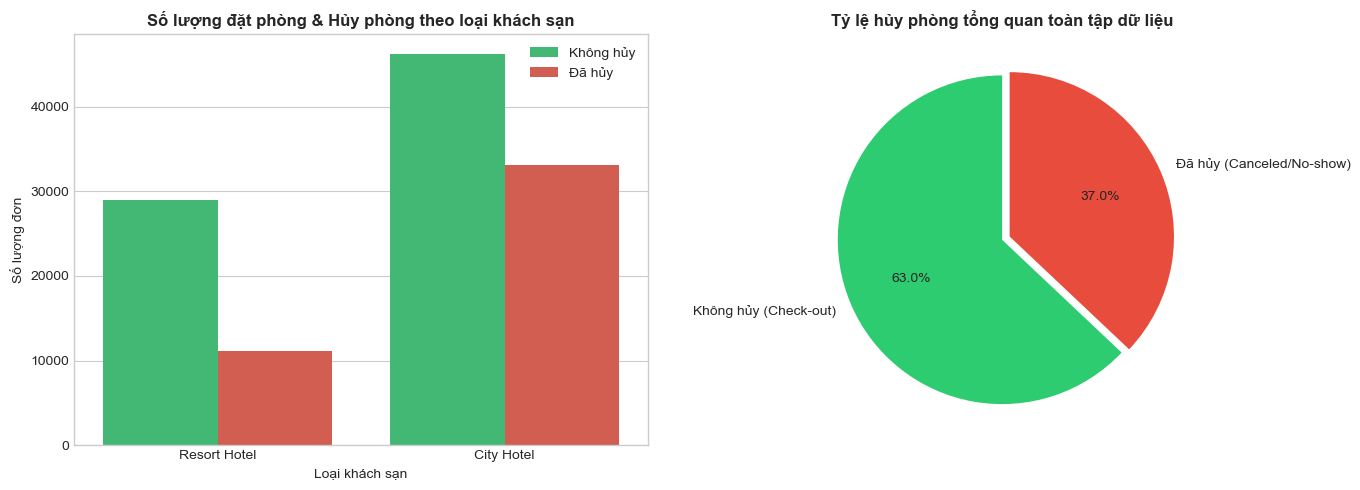

In [12]:
cancel_by_hotel = df.groupby('hotel')['is_canceled'].value_counts(normalize=True).unstack() * 100
cancel_by_hotel.columns = ['Không hủy (0)', 'Đã hủy (1)']
print(cancel_by_hotel)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x='hotel', hue='is_canceled', ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Số lượng đặt phòng & Hủy phòng theo loại khách sạn', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Loại khách sạn')
axes[0].set_ylabel('Số lượng đơn')
axes[0].legend(['Không hủy', 'Đã hủy'])

df['is_canceled'].value_counts().plot.pie(
ax=axes[1], autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], 
labels=['Không hủy (Check-out)', 'Đã hủy (Canceled/No-show)'], startangle=90, explode=[0, 0.05]
)
axes[1].set_title('Tỷ lệ hủy phòng tổng quan toàn tập dữ liệu', fontsize=12, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

**Insight 1:**
- **City Hotel** có lượng đặt phòng áp đảo (~66.4%) so với **Resort Hotel** (~33.6%).
- Tỷ lệ hủy phòng tại **City Hotel** cao hơn rõ rệt (~41.7%) so với **Resort Hotel** (~27.8%).

### 5.2 Mùa vụ & Xu hướng đặt phòng theo tháng (`arrival_date_month`)

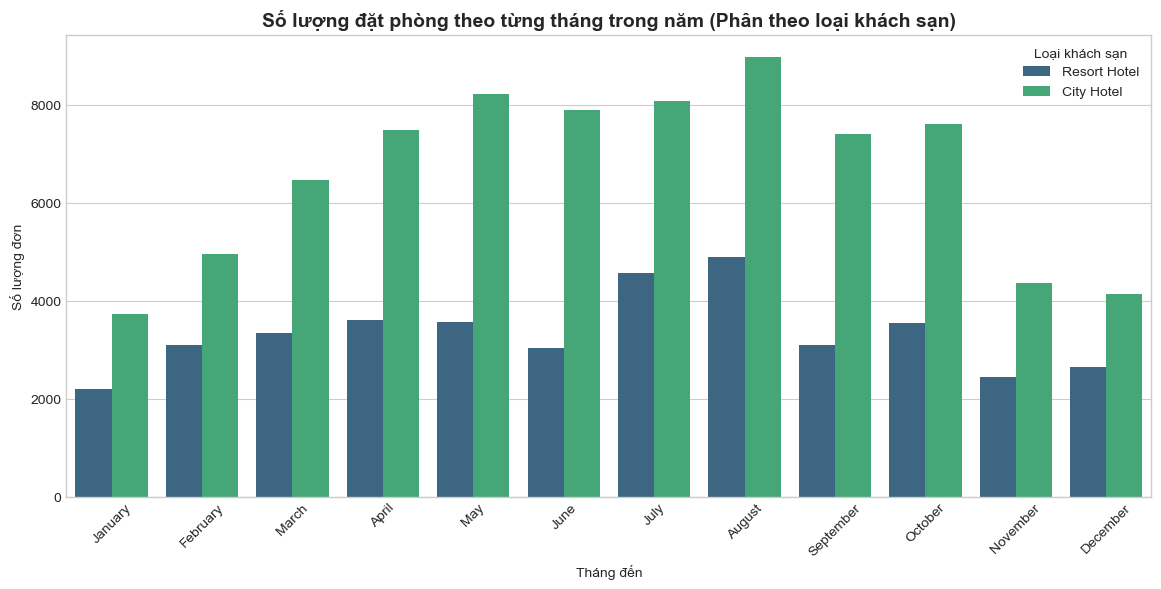

In [13]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
'July', 'August', 'September', 'October', 'November', 'December']

plt.figure(figsize=(14, 6))
sns.countplot(data=df, x='arrival_date_month', hue='hotel', order=month_order, palette='viridis')
plt.title('Số lượng đặt phòng theo từng tháng trong năm (Phân theo loại khách sạn)', fontsize=14, fontweight='bold')
plt.xlabel('Tháng đến')
plt.ylabel('Số lượng đơn')
plt.xticks(rotation=45)
plt.legend(title='Loại khách sạn')
plt.show()

**Insight 2:**
- Tháng cao điểm đặt phòng du lịch nhiều nhất trong năm là **tháng 7 và tháng 8** (mùa hè).
- Tháng thấp điểm nhất là **tháng 11, 12 và tháng 1** (mùa đông).

### 5.3 Phân khúc thị trường (`market_segment`) & Kênh phân phối (`distribution_channel`)

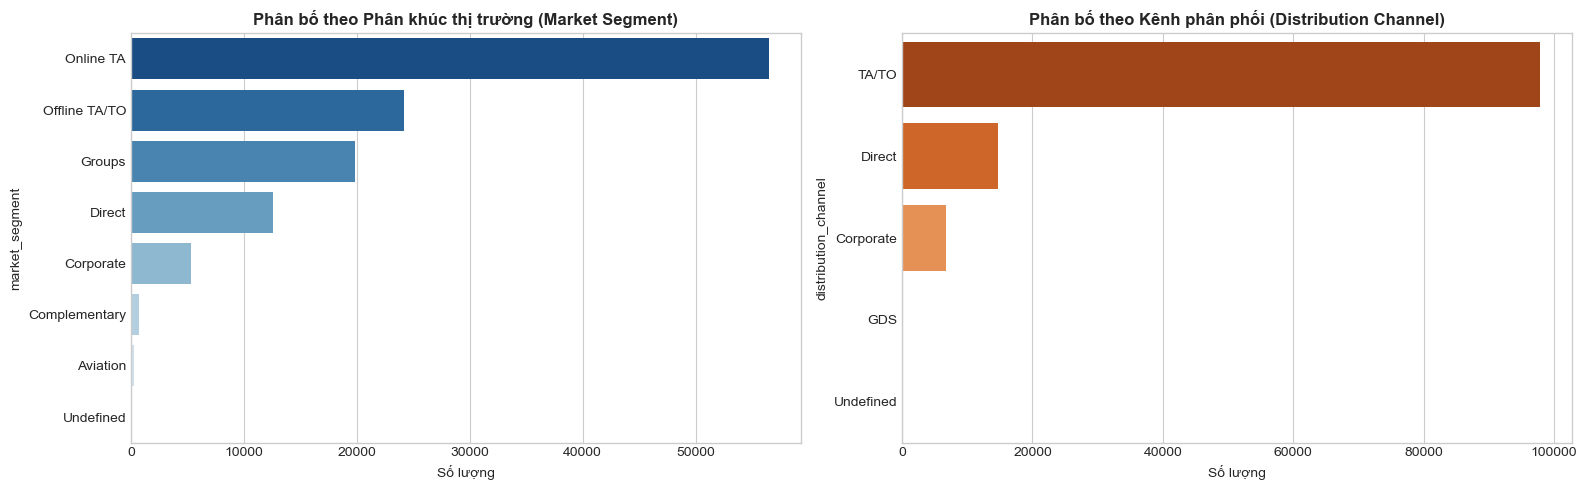

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.countplot(data=df, y='market_segment', order=df['market_segment'].value_counts().index, ax=axes[0], palette='Blues_r')
axes[0].set_title('Phân bố theo Phân khúc thị trường (Market Segment)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Số lượng')

sns.countplot(data=df, y='distribution_channel', order=df['distribution_channel'].value_counts().index, ax=axes[1], palette='Oranges_r')
axes[1].set_title('Phân bố theo Kênh phân phối (Distribution Channel)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Số lượng')

plt.tight_layout()
plt.show()

### 5.4 Thời gian đặt trước (`lead_time`) tác động như thế nào đến việc hủy phòng?

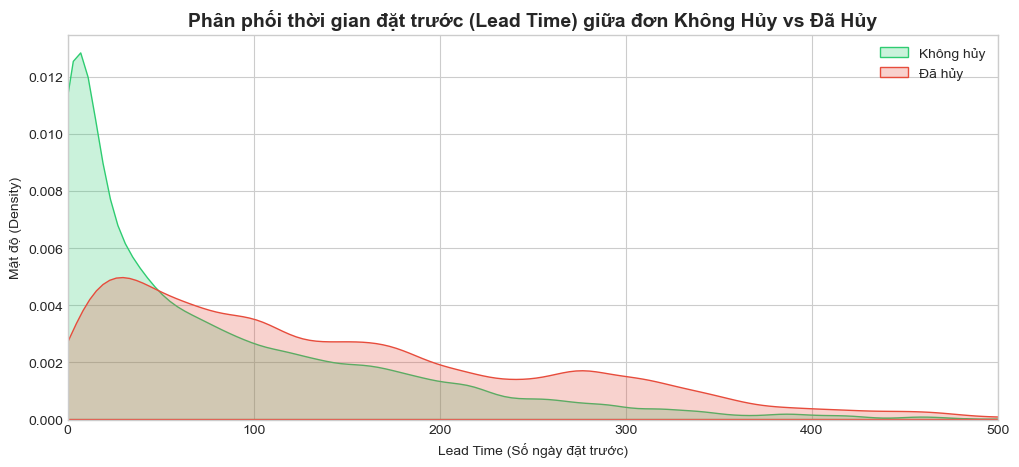

             count   mean  median    std
is_canceled                             
0            75166  79.98   45.00  91.11
1            44224 144.85  113.00 118.62


In [15]:
plt.figure(figsize=(12, 5))
sns.kdeplot(data=df[df['is_canceled'] == 0]['lead_time'], label='Không hủy', shade=True, color='#2ecc71')
sns.kdeplot(data=df[df['is_canceled'] == 1]['lead_time'], label='Đã hủy', shade=True, color='#e74c3c')
plt.title('Phân phối thời gian đặt trước (Lead Time) giữa đơn Không Hủy vs Đã Hủy', fontsize=14, fontweight='bold')
plt.xlabel('Lead Time (Số ngày đặt trước)')
plt.ylabel('Mật độ (Density)')
plt.xlim(0, 500)
plt.legend()
plt.show()

print(df.groupby('is_canceled')['lead_time'].agg(['count', 'mean', 'median', 'std']))

**Insight 3:**
- Khách hàng hủy phòng có `lead_time` trung bình **144.8 ngày** (median: 113 ngày), cao hơn rất nhiều so với khách không hủy (trung bình **79.9 ngày**, median: 49 ngày).
- **Quy luật:** Đặt phòng càng xa ngày nhận phòng thì rủi ro hủy phòng càng cao.

### 5.5 Giá phòng trung bình ngày (`ADR`) theo tháng và loại khách sạn

AttributeError: Line2D.set() got an unexpected keyword argument 'order'

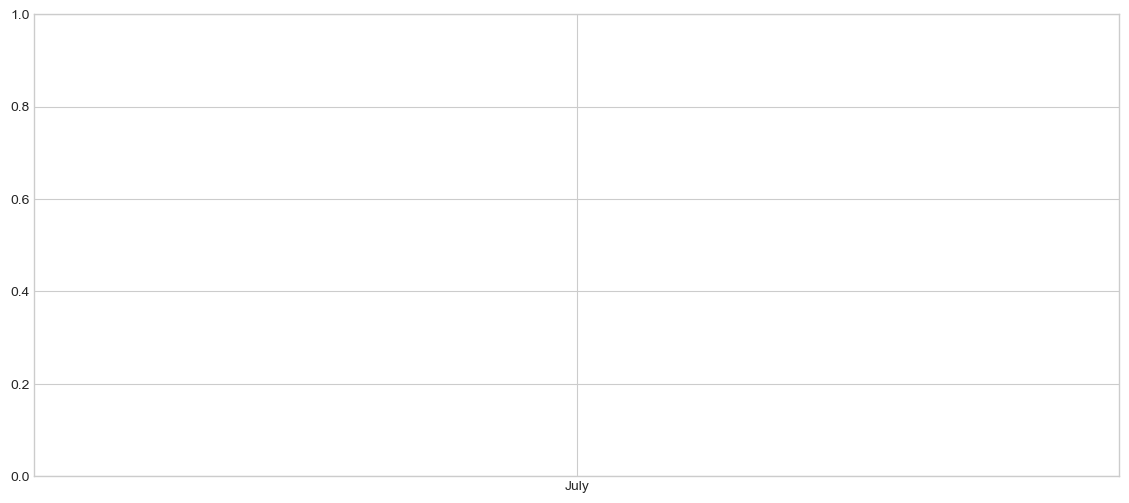

In [16]:
df_adr_valid = df[(df['adr'] > 0) & (df['adr'] < 1000)]

plt.figure(figsize=(14, 6))
sns.lineplot(
data=df_adr_valid, 
x='arrival_date_month', 
y='adr', 
hue='hotel', 
estimator='mean', 
ci=None, 
order=month_order,
marker='o',
palette=['#3498db', '#e67e22']
)
plt.title('Biến động Giá phòng trung bình ngày (ADR) theo tháng', fontsize=14, fontweight='bold')
plt.xlabel('Tháng')
plt.ylabel('Giá phòng trung bình (ADR - €)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Insight 4:**
- **Resort Hotel:** Giá phòng tăng vọt và đạt đỉnh vào tháng 7, 8 (~140 - 180 €) do mùa du lịch biển, sau đó giảm mạnh vào mùa đông.
- **City Hotel:** Giá phòng tương đối ổn định quanh mức 90 - 120 € quanh năm, đạt đỉnh nhẹ vào tháng 5 và tháng 9 (mùa công tác & du lịch tham quan đô thị).

### 5.6 Phân bố địa lý khách hàng (Top 10 quốc gia)

In [ ]:
top_10_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_10_countries.values, y=top_10_countries.index, palette='crest')
plt.title('Top 10 Quốc gia có lượng khách đặt phòng nhiều nhất', fontsize=14, fontweight='bold')
plt.xlabel('Số lượng đơn đặt phòng')
plt.ylabel('Mã quốc gia (ISO)')
for i, v in enumerate(top_10_countries.values):
    plt.text(v + 500, i, f"{v:,} ({v/len(df)*100:.1f}%)", va='center')
plt.xlim(0, 55000)
plt.show()

**Insight 5:**
- **Bồ Đào Nha (PRT)** chiếm tỷ trọng lớn nhất với hơn **48,590 lượt đặt phòng (~40.7%)**.
- Tiếp theo là các quốc gia Châu Âu lân cận: **GBR (Anh), FRA (Pháp), ESP (Tây Ban Nha), DEU (Đức), ITA (Ý)**.

### 5.7 Ma trận tương quan giữa các biến số (Correlation Heatmap)

In [ ]:
num_cols = df.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(14, 10))
corr_matrix = df[num_cols].corr()
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, vmin=-0.4, vmax=1, linewidths=0.5)
plt.title('Ma trận tương quan giữa các thuộc tính số trong tập dữ liệu', fontsize=14, fontweight='bold')
plt.show()

## 6. Tổng kết các phát hiện quan trọng (Key Takeaways)

Qua bước **Data Understanding**, chúng ta đã nắm được các điểm mấu chốt sau:

| Vấn đề | Hiện trạng trong dữ liệu | Đề xuất giải pháp xử lý trong `cleaning.ipynb` |
| :--- | :--- | :--- |
| **Missing Values** | `company` (94.3%), `agent` (13.7%), `country` (0.4%), `children` (4 dòng). | - `company` & `agent`: Điền `0` (không qua đại lý/cty).<br>- `country`: Điền Mode hoặc `'Unknown'`.<br>- `children`: Điền `0`. |
| **Duplicates** | 31,994 dòng trùng lặp (26.8%). | Đánh giá và loại bỏ dòng trùng lặp (`drop_duplicates`). |
| **Dữ liệu vô lý (Anomalies)** | 180 dòng có 0 khách (`adults + children + babies == 0`). | Lọc bỏ các dòng có tổng số khách bằng 0. |
| **Ngoại lai ADR** | `adr` có giá trị âm (`-6.38`) và cực trị (`5400.0`). | Lọc bỏ giá trị `adr <= 0` hoặc chuẩn hóa ngoại lai. |
| **Giá trị 'Undefined'** | Xuất hiện trong `meal`, `market_segment`, `distribution_channel`. | - `meal`: Thay `'Undefined'` bằng `'SC'`.<br>- Các cột còn lại: Xử lý về giá trị hợp lệ. |
| **Kiểu dữ liệu (Data Types)** | `children`, `agent`, `company` là `float64`; `reservation_status_date` là `object`. | Chuyển đổi về đúng kiểu `int64` và `datetime64`. |
| **Feature Engineering** | Cần thêm các biến hỗ trợ phân tích: Tổng đêm lưu trú, Tổng số khách, Thay đổi phòng... | Tạo thêm các cột phái sinh mới trong bước làm sạch. |

---
**Bước tiếp theo:** Mời bạn mở notebook [`cleaning.ipynb`](cleaning.ipynb) để thực hiện quy trình tiền xử lý và làm sạch dữ liệu chi tiết!